# Data Analyst Job Market — Exploratory Data Analysis

## Overview

This exploratory analysis complements the SQL-based investigation of top-paying Data Analyst job postings.

The analysis focuses on:
- salary distribution across selected roles
- demand for analytical and technical skills
- skill coverage across job postings
- relationship between salary and the breadth of listed skills

The source data is at **job-skill grain**, where a job can have multiple rows because each required skill is represented separately.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("top skills.csv")
df = pd.read_csv(DATA_PATH)

df["skills"] = df["skills"].astype(str).str.strip().str.lower()
df["company_name"] = df["company_name"].astype(str).str.strip()

df.head()


,job_id,job_title,salary_year_avg,company_name,skills
0,552322,Associate Director- Data Insights,255829.5,AT&T,sql
1,552322,Associate Director- Data Insights,255829.5,AT&T,python
2,552322,Associate Director- Data Insights,255829.5,AT&T,r
3,552322,Associate Director- Data Insights,255829.5,AT&T,azure
4,552322,Associate Director- Data Insights,255829.5,AT&T,databricks


## Data Overview

In [2]:
overview = pd.DataFrame({
    "Metric": ["Job-skill rows", "Unique job postings", "Unique companies", "Unique skills"],
    "Value": [
        len(df),
        df["job_id"].nunique(),
        df["company_name"].nunique(),
        df["skills"].nunique()
    ]
})
display(overview)

display(df.isna().sum().rename("missing_values").to_frame())


,Metric,Value
0,Job-skill rows,66
1,Unique job postings,8
2,Unique companies,7
3,Unique skills,28


,missing_values
job_id,0
job_title,0
salary_year_avg,0
company_name,0
skills,0


## Salary Analysis

Salary statistics are calculated at **job level** to avoid giving jobs with more listed skills disproportionate weight.

In [3]:
jobs = (
    df[["job_id","job_title","salary_year_avg","company_name"]]
    .drop_duplicates("job_id")
    .sort_values("salary_year_avg", ascending=False)
)
jobs["skill_count"] = jobs["job_id"].map(df.groupby("job_id")["skills"].nunique())
display(jobs)
display(jobs["salary_year_avg"].describe())


,job_id,job_title,salary_year_avg,company_name,skill_count
0,552322,Associate Director- Data Insights,255829.5,AT&T,13
13,99305,"Data Analyst, Marketing",232423.0,Pinterest Job Advertisements,5
18,1021647,Data Analyst (Hybrid/Remote),217000.0,Uclahealthcareers,5
23,168310,Principal Data Analyst (Remote),205000.0,SmartAsset,9
32,731368,"Director, Data Analyst - HYBRID",189309.0,Inclusively,14
46,310660,"Principal Data Analyst, AV Performance Analysis",189000.0,Motional,8
54,1749593,Principal Data Analyst,186000.0,SmartAsset,9
63,387860,ERM Data Analyst,184000.0,Get It Recruit - Information Technology,3


count         8.000000
mean     207320.187500
std       26024.165473
min      184000.000000
25%      188250.000000
50%      197154.500000
75%      220855.750000
max      255829.500000
Name: salary_year_avg, dtype: float64

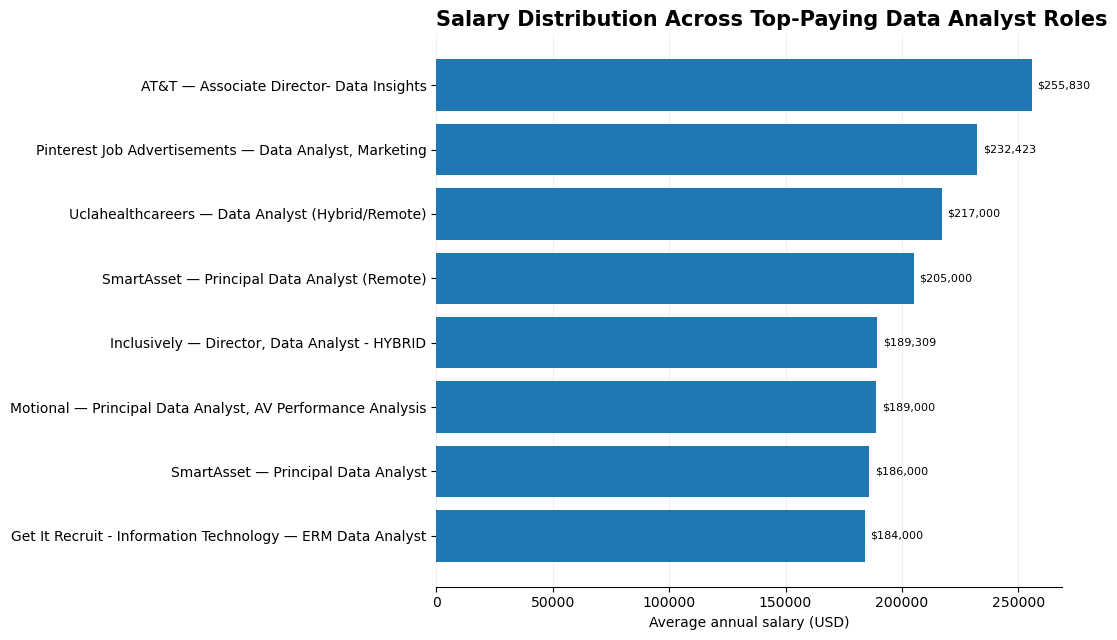

In [4]:
j = jobs.sort_values("salary_year_avg")
labels = (j["company_name"] + " — " + j["job_title"]).str.slice(0,60)

fig, ax = plt.subplots(figsize=(11,6.5))
bars = ax.barh(labels, j["salary_year_avg"])
ax.set_title("Salary Distribution Across Top-Paying Data Analyst Roles", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Average annual salary (USD)")
ax.spines[["top","right","left"]].set_visible(False)
ax.grid(axis="x", alpha=.2); ax.set_axisbelow(True)
ax.bar_label(bars, labels=[f"${x:,.0f}" for x in j["salary_year_avg"]], padding=4, fontsize=8)
plt.tight_layout()
plt.show()


## Skill Demand

Skill frequency is measured by the number of distinct job postings containing each skill.

In [5]:
skill_counts = (
    df.groupby("skills")["job_id"]
      .nunique()
      .sort_values(ascending=False)
)
skill_summary = skill_counts.rename("job_postings").reset_index().rename(columns={"skills":"skill"})
skill_summary["coverage_pct"] = (
    skill_summary["job_postings"] / df["job_id"].nunique() * 100
).round(1)
display(skill_summary.head(15))


,skill,job_postings,coverage_pct
0,sql,8,100.0
1,python,7,87.5
2,tableau,6,75.0
3,r,4,50.0
4,excel,3,37.5
5,pandas,3,37.5
6,snowflake,3,37.5
7,confluence,2,25.0
8,bitbucket,2,25.0
9,atlassian,2,25.0


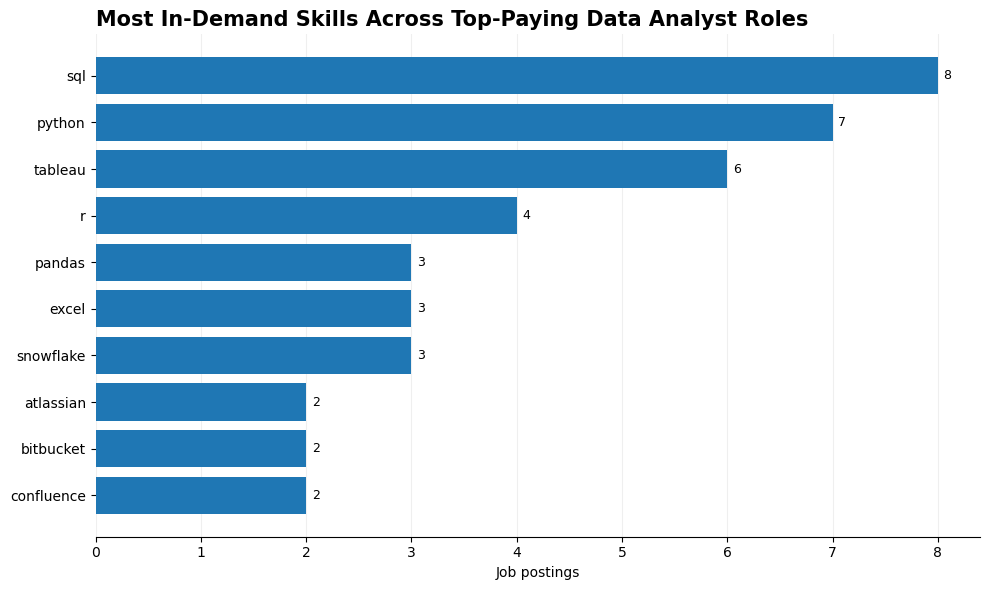

In [6]:
top = skill_counts.head(10).sort_values()

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top.index, top.values)
ax.set_title("Most In-Demand Skills Across Top-Paying Data Analyst Roles", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Job postings")
ax.spines[["top","right","left"]].set_visible(False)
ax.grid(axis="x", alpha=.2); ax.set_axisbelow(True)
ax.bar_label(bars, padding=4, fontsize=9)
plt.tight_layout()
plt.show()


## Skill Coverage Across Job Postings

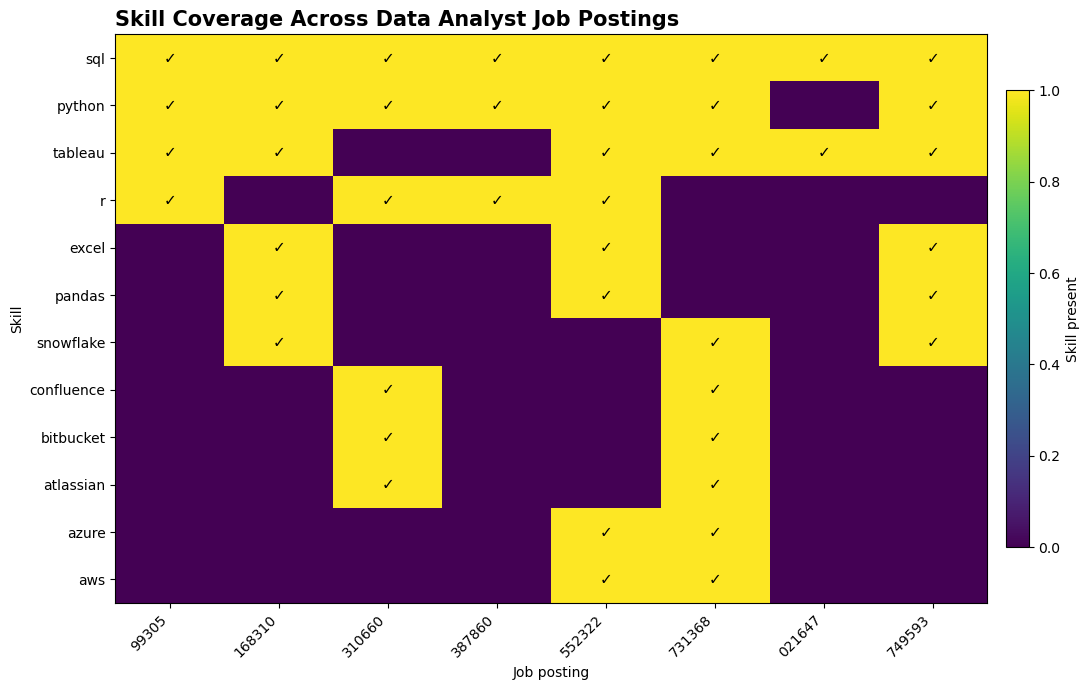

In [7]:
pivot = pd.crosstab(df["skills"], df["job_id"])
top_skills = skill_counts.head(12).index
mat = pivot.loc[top_skills].fillna(0)

fig, ax = plt.subplots(figsize=(11,7))
im = ax.imshow(mat.values, aspect="auto")
ax.set_title("Skill Coverage Across Data Analyst Job Postings", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Job posting")
ax.set_ylabel("Skill")
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels([str(x)[-6:] for x in mat.columns], rotation=45, ha="right")
for i in range(mat.shape[0]):
    for k in range(mat.shape[1]):
        if mat.iloc[i,k]:
            ax.text(k,i,"✓",ha="center",va="center",fontsize=11)
fig.colorbar(im, ax=ax, fraction=.025, pad=.02, label="Skill present")
plt.tight_layout()
plt.show()


## Salary and Skill Breadth

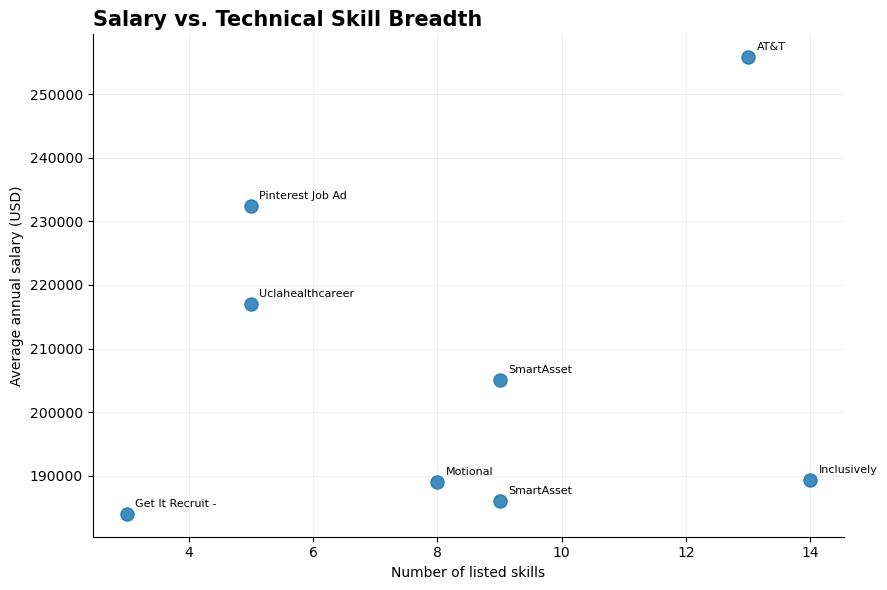

In [8]:
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(jobs["skill_count"], jobs["salary_year_avg"], s=90, alpha=.85)

for _, row in jobs.iterrows():
    ax.annotate(
        str(row["company_name"])[:16],
        (row["skill_count"], row["salary_year_avg"]),
        xytext=(6,5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Salary vs. Technical Skill Breadth", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of listed skills")
ax.set_ylabel("Average annual salary (USD)")
ax.spines[["top","right"]].set_visible(False)
ax.grid(alpha=.18); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## Key Findings

- SQL is the most consistently represented skill in the selected job postings.
- Python and BI/visualization skills are also prominent, indicating a broader analytical stack beyond SQL alone.
- Salary varies considerably even among selected high-paying Data Analyst roles.
- The number of listed skills differs across roles, but skill count by itself does not establish a salary relationship.
- Skill-level salary comparisons are descriptive associations and should not be interpreted as causal effects.
- The exported skill dataset contains multiple rows per job because of its job-skill grain; job-level metrics are therefore calculated after deduplication to one row per job.

